In [1]:
import copy
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

NUM_CLIENTS  = 10
NUM_ROUNDS   = 20
LOCAL_EPOCHS = 3
BATCH_SIZE   = 32
LR           = 0.01

MALICIOUS_CLIENTS = [0, 1, 2]
SOURCE_CLASS      = 1
TARGET_CLASS      = 7
POISON_RATIO      = 1.0

STEALTH_START = 2.0
STEALTH_END   = 0.5
BOOST_START   = 2.0
BOOST_END     = 3.2

Using device: cpu


In [3]:
transform = transforms.Compose([transforms.ToTensor()])

train_dataset = datasets.MNIST(root="./data", train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

print("Train size:", len(train_dataset))
print("Test size:",  len(test_dataset))

Train size: 60000
Test size: 10000


In [4]:
all_indices = np.arange(len(train_dataset))
np.random.shuffle(all_indices)
client_indices = np.array_split(all_indices, NUM_CLIENTS)

for i, idxs in enumerate(client_indices):
    print(f"Client {i}: {len(idxs)} samples")

Client 0: 6000 samples
Client 1: 6000 samples
Client 2: 6000 samples
Client 3: 6000 samples
Client 4: 6000 samples
Client 5: 6000 samples
Client 6: 6000 samples
Client 7: 6000 samples
Client 8: 6000 samples
Client 9: 6000 samples


In [5]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

global_model = SimpleCNN().to(device)
print(global_model)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [6]:
class PoisonedSubset(torch.utils.data.Dataset):
    def __init__(self, dataset, indices, malicious=False,
                 source_class=1, target_class=7, poison_ratio=1.0):
        self.dataset = dataset
        self.indices = list(indices)
        self.malicious = malicious
        self.source_class = source_class
        self.target_class = target_class

        self.poisoned_positions = set()
        if self.malicious:
            source_positions = [
                pos for pos, idx in enumerate(self.indices)
                if int(self.dataset[idx][1]) == self.source_class
            ]
            n_poison = int(len(source_positions) * poison_ratio)
            self.poisoned_positions = set(source_positions[:n_poison])

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        idx = self.indices[i]
        x, y = self.dataset[idx]
        y = int(y)
        if self.malicious and i in self.poisoned_positions:
            y = self.target_class
        return x, y

In [7]:
def train_local(model, dataset, epochs=1, batch_size=32, lr=0.01):
    model.train()
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)
    for _ in range(epochs):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()
    return model.state_dict()


def malicious_train_pgd(global_state, poisoned_dataset,
                        epochs, batch_size, lr, stealth_weight):
    model = SimpleCNN().to(device)
    model.load_state_dict(global_state)
    model.train()

    loader    = DataLoader(poisoned_dataset, batch_size=batch_size, shuffle=True)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)

    global_params = {
        k: v.clone().detach().float()
        for k, v in global_state.items()
        if v.dtype in (torch.float32, torch.float64)
    }

    for _ in range(epochs):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()

            task_loss = criterion(model(x), y)

            stealth_loss = 0.0
            for name, param in model.named_parameters():
                if name in global_params:
                    stealth_loss = stealth_loss + ((param - global_params[name]) ** 2).sum()

            total_loss = task_loss + stealth_weight * stealth_loss
            total_loss.backward()
            optimizer.step()

    return model.state_dict()

In [8]:
def fedavg(state_dicts):
    avg_state = copy.deepcopy(state_dicts[0])
    for key in avg_state.keys():
        for i in range(1, len(state_dicts)):
            avg_state[key] += state_dicts[i][key]
        avg_state[key] = avg_state[key] / len(state_dicts)
    return avg_state

In [9]:
def evaluate_mta_asr(model, test_dataset,
                     source_class=1, target_class=7, batch_size=256):
    model.eval()
    loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    correct = 0
    total = 0
    source_total = 0
    source_to_target = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            preds = torch.argmax(outputs, dim=1)

            correct += (preds == y).sum().item()
            total += y.size(0)

            mask = (y == source_class)
            source_total += mask.sum().item()
            source_to_target += ((preds == target_class) & mask).sum().item()

    mta = correct / total
    asr = source_to_target / source_total if source_total > 0 else 0.0

    return mta, asr

In [10]:
mta_history = []
asr_history = []

for rnd in range(NUM_ROUNDS):
    local_states = []

    progress       = rnd / (NUM_ROUNDS - 1)
    stealth_weight = STEALTH_START + (STEALTH_END - STEALTH_START) * progress
    boost_factor   = BOOST_START   + (BOOST_END   - BOOST_START)   * progress

    for client_id in range(NUM_CLIENTS):
        is_malicious = client_id in MALICIOUS_CLIENTS

        if is_malicious:
            poisoned_dataset = PoisonedSubset(
                dataset      = train_dataset,
                indices      = client_indices[client_id],
                malicious    = True,
                source_class = SOURCE_CLASS,
                target_class = TARGET_CLASS,
                poison_ratio = POISON_RATIO
            )

            local_state = malicious_train_pgd(
                global_state     = global_model.state_dict(),
                poisoned_dataset = poisoned_dataset,
                epochs           = LOCAL_EPOCHS,
                batch_size       = BATCH_SIZE,
                lr               = LR,
                stealth_weight   = stealth_weight
            )

            global_state = global_model.state_dict()
            for key in local_state.keys():
                delta            = local_state[key].float() - global_state[key].float()
                local_state[key] = global_state[key] + boost_factor * delta

        else:
            local_model = SimpleCNN().to(device)
            local_model.load_state_dict(global_model.state_dict())

            honest_dataset = PoisonedSubset(
                dataset      = train_dataset,
                indices      = client_indices[client_id],
                malicious    = False,
                source_class = SOURCE_CLASS,
                target_class = TARGET_CLASS,
                poison_ratio = 0.0
            )
            local_state = train_local(
                model      = local_model,
                dataset    = honest_dataset,
                epochs     = LOCAL_EPOCHS,
                batch_size = BATCH_SIZE,
                lr         = LR
            )

        local_states.append(local_state)

    new_global_state = fedavg(local_states)
    global_model.load_state_dict(new_global_state)

    mta, asr = evaluate_mta_asr(
        model        = global_model,
        test_dataset = test_dataset,
        source_class = SOURCE_CLASS,
        target_class = TARGET_CLASS
    )

    mta_history.append(mta)
    asr_history.append(asr)
    print(f"Round {rnd+1:02d} | stealth={stealth_weight:.2f} | boost={boost_factor:.2f} | MTA: {mta:.4f} | ASR: {asr:.4f}")

Round 01 | stealth=2.00 | boost=2.00 | MTA: 0.7891 | ASR: 0.0009
Round 02 | stealth=1.92 | boost=2.06 | MTA: 0.8802 | ASR: 0.0035
Round 03 | stealth=1.84 | boost=2.13 | MTA: 0.8922 | ASR: 0.0687
Round 04 | stealth=1.76 | boost=2.19 | MTA: 0.9205 | ASR: 0.0176
Round 05 | stealth=1.68 | boost=2.25 | MTA: 0.9209 | ASR: 0.1207
Round 06 | stealth=1.61 | boost=2.32 | MTA: 0.9382 | ASR: 0.0520
Round 07 | stealth=1.53 | boost=2.38 | MTA: 0.9225 | ASR: 0.2291
Round 08 | stealth=1.45 | boost=2.44 | MTA: 0.9512 | ASR: 0.0555
Round 09 | stealth=1.37 | boost=2.51 | MTA: 0.9358 | ASR: 0.2176
Round 10 | stealth=1.29 | boost=2.57 | MTA: 0.9490 | ASR: 0.0793
Round 11 | stealth=1.21 | boost=2.63 | MTA: 0.9530 | ASR: 0.0960
Round 12 | stealth=1.13 | boost=2.69 | MTA: 0.9505 | ASR: 0.1665
Round 13 | stealth=1.05 | boost=2.76 | MTA: 0.9490 | ASR: 0.1736
Round 14 | stealth=0.97 | boost=2.82 | MTA: 0.9476 | ASR: 0.1956
Round 15 | stealth=0.89 | boost=2.88 | MTA: 0.9432 | ASR: 0.2458
Round 16 | stealth=0.82 |

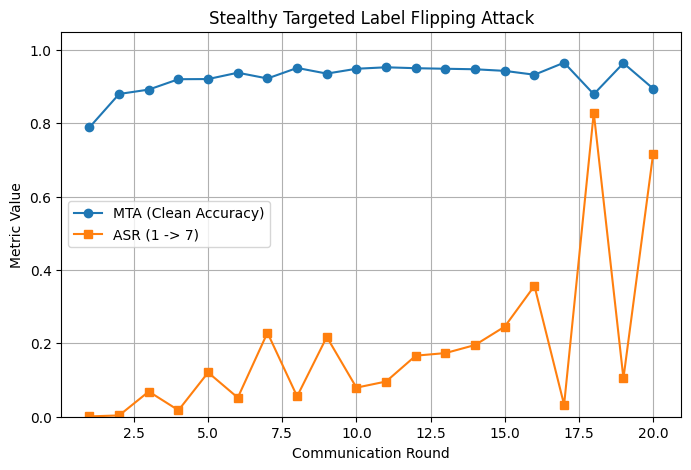

Final MTA: 0.895
Final ASR: 0.7162995594713656


In [11]:
rounds = np.arange(1, NUM_ROUNDS + 1)

plt.figure(figsize=(8, 5))
plt.plot(rounds, mta_history, marker='o', label='MTA (Clean Accuracy)')
plt.plot(rounds, asr_history, marker='s', label='ASR (1 -> 7)')
plt.xlabel("Communication Round")
plt.ylabel("Metric Value")
plt.title("Stealthy Targeted Label Flipping Attack")
plt.legend()
plt.grid(True)
plt.ylim(0, 1.05)
plt.show()

print("Final MTA:", mta_history[-1])
print("Final ASR:", asr_history[-1])

In [12]:
def run_multi_client_adaptive_experiment(malicious_clients, experiment_name):
    global_model = SimpleCNN().to(device)

    mta_history = []
    asr_history = []

    for rnd in range(NUM_ROUNDS):
        local_states = []

        progress       = rnd / (NUM_ROUNDS - 1)
        stealth_weight = STEALTH_START + (STEALTH_END - STEALTH_START) * progress
        boost_factor   = BOOST_START + (BOOST_END - BOOST_START) * progress

        for client_id in range(NUM_CLIENTS):
            is_malicious = client_id in malicious_clients

            if is_malicious:
                poisoned_dataset = PoisonedSubset(
                    dataset=train_dataset,
                    indices=client_indices[client_id],
                    malicious=True,
                    source_class=SOURCE_CLASS,
                    target_class=TARGET_CLASS,
                    poison_ratio=POISON_RATIO
                )

                local_state = malicious_train_pgd(
                    global_state=global_model.state_dict(),
                    poisoned_dataset=poisoned_dataset,
                    epochs=LOCAL_EPOCHS,
                    batch_size=BATCH_SIZE,
                    lr=LR,
                    stealth_weight=stealth_weight
                )

                global_state = global_model.state_dict()
                for key in local_state.keys():
                    delta = local_state[key].float() - global_state[key].float()
                    local_state[key] = global_state[key] + boost_factor * delta

            else:
                local_model = SimpleCNN().to(device)
                local_model.load_state_dict(global_model.state_dict())

                honest_dataset = PoisonedSubset(
                    dataset=train_dataset,
                    indices=client_indices[client_id],
                    malicious=False,
                    source_class=SOURCE_CLASS,
                    target_class=TARGET_CLASS,
                    poison_ratio=0.0
                )

                local_state = train_local(
                    model=local_model,
                    dataset=honest_dataset,
                    epochs=LOCAL_EPOCHS,
                    batch_size=BATCH_SIZE,
                    lr=LR
                )

            local_states.append(local_state)

        new_global_state = krum(local_states, num_malicious=len(malicious_clients))
        global_model.load_state_dict(new_global_state)

        mta, asr = evaluate_mta_asr(
            model=global_model,
            test_dataset=test_dataset,
            source_class=SOURCE_CLASS,
            target_class=TARGET_CLASS
        )

        mta_history.append(mta)
        asr_history.append(asr)

        print(
            f"{experiment_name} | Round {rnd+1:02d} | "
            f"MTA: {mta:.4f} | ASR: {asr:.4f}"
        )

    return mta_history, asr_history

In [13]:
import copy
import torch

def flatten_weights(state_dict):
    return torch.cat([
        v.flatten().float().cpu()
        for v in state_dict.values()
    ])

def krum(local_states, num_malicious):

    num_clients = len(local_states)

    flattened_updates = [
        flatten_weights(w)
        for w in local_states
    ]

    scores = []

    for i in range(num_clients):

        distances = []

        for j in range(num_clients):

            if i != j:
                dist = torch.norm(
                    flattened_updates[i] - flattened_updates[j]
                ) ** 2

                distances.append(dist.item())

        distances.sort()

        nb_count = num_clients - num_malicious - 2

        score = sum(distances[:nb_count])

        scores.append(score)

    selected_index = scores.index(min(scores))

    return copy.deepcopy(local_states[selected_index])

In [14]:
multi_client_results = {}

client_settings = {
    "1 Malicious Client": [0],
    "3 Malicious Clients": [0, 1, 2],
    "5 Malicious Clients": [0, 1, 2, 3, 4]
}

for name, clients in client_settings.items():
    print("\nRunning:", name)

    mta_hist, asr_hist = run_multi_client_adaptive_experiment(
        malicious_clients=clients,
        experiment_name=name
    )

    multi_client_results[name] = {
        "mta": mta_hist,
        "asr": asr_hist,
        "final_mta": mta_hist[-1],
        "final_asr": asr_hist[-1]
    }


Running: 1 Malicious Client
1 Malicious Client | Round 01 | MTA: 0.8213 | ASR: 0.0000
1 Malicious Client | Round 02 | MTA: 0.8924 | ASR: 0.0000
1 Malicious Client | Round 03 | MTA: 0.9127 | ASR: 0.0009
1 Malicious Client | Round 04 | MTA: 0.9365 | ASR: 0.0018
1 Malicious Client | Round 05 | MTA: 0.9073 | ASR: 0.0018
1 Malicious Client | Round 06 | MTA: 0.9456 | ASR: 0.0018
1 Malicious Client | Round 07 | MTA: 0.9519 | ASR: 0.0018
1 Malicious Client | Round 08 | MTA: 0.9582 | ASR: 0.0000
1 Malicious Client | Round 09 | MTA: 0.9601 | ASR: 0.0009
1 Malicious Client | Round 10 | MTA: 0.9592 | ASR: 0.0009
1 Malicious Client | Round 11 | MTA: 0.9640 | ASR: 0.0009
1 Malicious Client | Round 12 | MTA: 0.9696 | ASR: 0.0000
1 Malicious Client | Round 13 | MTA: 0.9618 | ASR: 0.0009
1 Malicious Client | Round 14 | MTA: 0.9725 | ASR: 0.0000
1 Malicious Client | Round 15 | MTA: 0.9707 | ASR: 0.0035
1 Malicious Client | Round 16 | MTA: 0.9740 | ASR: 0.0000
1 Malicious Client | Round 17 | MTA: 0.9677

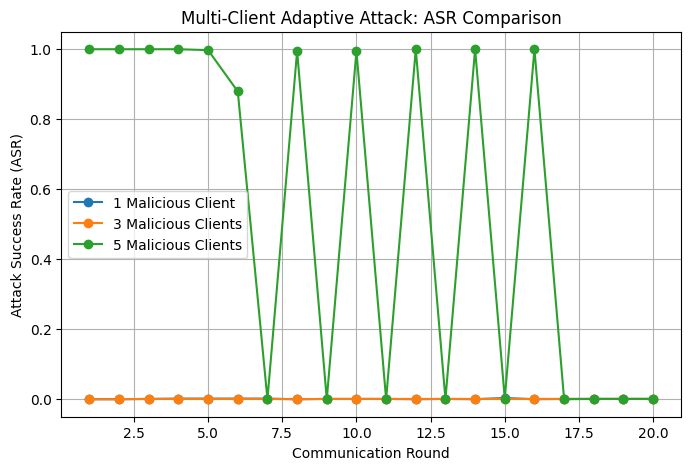

In [15]:
rounds = np.arange(1, NUM_ROUNDS + 1)

plt.figure(figsize=(8, 5))

for name, result in multi_client_results.items():
    plt.plot(rounds, result["asr"], marker="o", label=name)

plt.xlabel("Communication Round")
plt.ylabel("Attack Success Rate (ASR)")
plt.title("Multi-Client Adaptive Attack: ASR Comparison")
plt.legend()
plt.grid(True)
plt.savefig("multi_client_adaptive_asr.png", dpi=300, bbox_inches="tight")
plt.show()

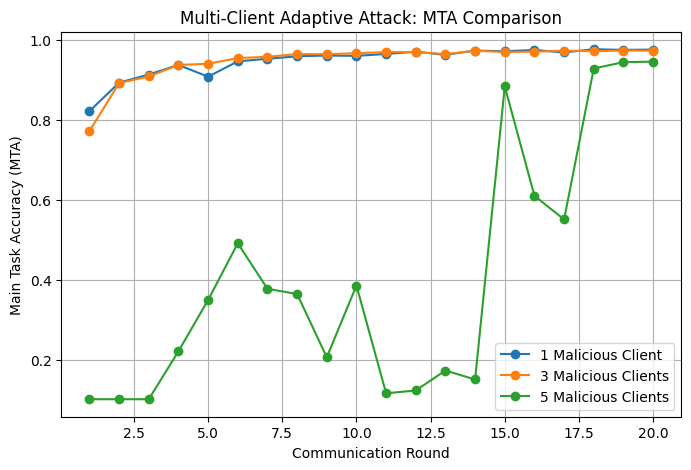

In [16]:
plt.figure(figsize=(8, 5))

for name, result in multi_client_results.items():
    plt.plot(rounds, result["mta"], marker="o", label=name)

plt.xlabel("Communication Round")
plt.ylabel("Main Task Accuracy (MTA)")
plt.title("Multi-Client Adaptive Attack: MTA Comparison")
plt.legend()
plt.grid(True)
plt.savefig("multi_client_adaptive_mta.png", dpi=300, bbox_inches="tight")
plt.show()

In [17]:
print("Final Multi-Client Adaptive Attack Comparison")
print("-" * 60)

for name, result in multi_client_results.items():
    print(
        f"{name}: Final MTA = {result['final_mta']:.4f}, "
        f"Final ASR = {result['final_asr']:.4f}"
    )

Final Multi-Client Adaptive Attack Comparison
------------------------------------------------------------
1 Malicious Client: Final MTA = 0.9749, Final ASR = 0.0009
3 Malicious Clients: Final MTA = 0.9723, Final ASR = 0.0009
5 Malicious Clients: Final MTA = 0.9448, Final ASR = 0.0009
